"Streaming, redes sociales y conciertos: construcción empírica del éxito de un artista musical"
Autora Silvana Contreras
Mayo 


In [11]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [12]:
import pandas as pd
import numpy as np

# levanto dataset

In [13]:
from pathlib import Path
import pandas as pd

df = pd.read_csv("dataset_4913_53.csv")
# df = pd.read_csv("dataset_7000_53.csv.csv")

print("Dimensiones:", df.shape)


Dimensiones: (4913, 53)


# dimensiones variables
creo tabla

In [14]:
# ============================================================
# Paso 2. Agrupación conceptual de variables
# Construcción de diccionario de variables
# ============================================================

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]

# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# ============================================================
# Tabla auxiliar con identidad conceptual de cada variable
# ============================================================

variable_dimension = []

for dimension, cols in column_groups.items():
    for col in cols:
        variable_dimension.append({
            "variable": col,
            "dimension": dimension
        })

df_variable_dimension = pd.DataFrame(variable_dimension)

# ============================================================
# Control de cobertura de columnas
# ============================================================

grouped_cols = df_variable_dimension["variable"].tolist()

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# ============================================================
# Resumen por dimensión
# ============================================================

resumen_dimensiones = (
    df_variable_dimension
    .groupby("dimension", as_index=False)
    .agg(n_variables=("variable", "count"))
    .sort_values("n_variables", ascending=False)
)

display(resumen_dimensiones)

# ============================================================
# Vista del diccionario de variables
# ============================================================

display(df_variable_dimension)

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []


,dimension,n_variables
3,playlists,15
2,metadata,10
1,live_events,8
5,streaming,7
4,redes_sociales,7
6,youtube,4
0,identificacion,2


,variable,dimension
0,chartmetric_id,identificacion
1,artist_name,identificacion
2,country,metadata
3,country_short,metadata
4,pronoun_title,metadata
5,pronoun_short,metadata
6,record_label,metadata
7,major_record_label,metadata
8,primary_genre,metadata
9,genre_short,metadata


# tipos datos

In [15]:
#recupero de la notebook previa

In [16]:
# 1. Definir el diccionario de tipos basado en tu info
dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# 2. Aplicar la conversión al dataframe df
# Código original que podía ocultar conversiones no aplicadas:
# df = df.astype(dtypes_dict, errors='ignore')

# Conversión solo de columnas existentes
dtypes_presentes = {
    col: dtype
    for col, dtype in dtypes_dict.items()
    if col in df.columns
}

df = df.astype(dtypes_presentes)

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4913 entries, 0 to 4912
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     4913 non-null   Int64   
 1   artist_name                        4913 non-null   str     
 2   country                            4909 non-null   category
 3   pronoun_title                      4913 non-null   category
 4   record_label                       4604 non-null   category
 5   primary_genre                      4913 non-null   category
 6   sp_followers                       4907 non-null   Int64   
 7   sp_monthly_listeners               4907 non-null   Int64   
 8   sp_popularity                      4911 non-null   float64 
 9   sp_playlist_total_reach            4913 non-null   float64 
 10  ins_followers                      4580 non-null   Int64   
 11  twitter_followers                  3968 non-null   Int

In [17]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (4913, 53)
Artistas únicos: 4913
Duplicados por chartmetric_id: 0
Nulos en target: 0
Tipo de dato de target: Int64


# SUBSET

# selección variables
pensando en la regresión lineal. para lightgbm pondría todas
selecciono las de alta multicolinealidad
y conservo las que no.

Selección de variables con umbral de correlación mayor a 0.7
tuve en cuenta múltiples pares, correlación maxima, promedio, corr target, nulls, explicabilidad

num_sp_playlists
num_az_playlists
sp_monthly_listeners
num_yt_editorial_playlists
tiktok_top_video_comments
sp_followers
pandora_lifetime_streams
tiktok_followers
ycs_views

+ 3 no multicolineales
'deezer_fans',
'ins_followers',
'twitter_followers'


In [18]:
# ============================================================
# Control de cobertura sobre todas las variables digitales
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Decisiones consolidadas sobre variables redundantes
# ------------------------------------------------------------

decision_consolidada = {
    "sp_playlist_total_reach": "descartar_preliminar",
    "num_sp_editorial_playlists": "descartar_preliminar",
    "num_am_editorial_playlists": "descartar_preliminar",
    "num_am_playlists": "descartar_preliminar",
    "num_sp_playlists": "conservar_preliminar",
    "num_de_playlists": "descartar_preliminar",
    "num_az_playlists": "conservar_preliminar",
    "sp_monthly_listeners": "conservar_preliminar",
    "num_de_editorial_playlists": "descartar_preliminar",
    "shazam_count": "descartar_preliminar",
    "num_yt_editorial_playlists": "conservar_preliminar",
    "num_yt_playlists": "descartar_preliminar",
    "num_az_editorial_playlists": "descartar_preliminar",
    "sp_popularity": "descartar_preliminar",
    "de_playlist_total_reach": "descartar_preliminar",
    "sp_editorial_playlist_total_reach": "descartar_preliminar",
    "tiktok_top_video_comments": "conservar_preliminar",
    "tiktok_top_video_views": "descartar_preliminar",
    "tiktok_track_posts": "descartar_preliminar",
    "de_editorial_playlist_total_reach": "descartar_preliminar",
    "sp_followers": "conservar_preliminar",
    "pandora_lifetime_stations_added": "descartar_preliminar",
    "pandora_lifetime_streams": "conservar_preliminar",
    "tiktok_followers": "conservar_preliminar",
    "tiktok_likes": "descartar_preliminar",
    "ycs_views": "conservar_preliminar",
    "ycs_subscribers": "descartar_preliminar",
    "yt_playlist_total_reach": "descartar_preliminar",
    "youtube_daily_video_views": "descartar_preliminar",
    "youtube_monthly_video_views": "descartar_preliminar"
}

# ------------------------------------------------------------
# Función auxiliar de dimensión
# ------------------------------------------------------------

def asignar_dimension(variable):
    if variable in streaming_cols:
        return "streaming"
    elif variable in playlist_cols:
        return "playlists"
    elif variable in social_cols:
        return "redes_sociales"
    elif variable in youtube_cols:
        return "youtube"
    else:
        return "otra"

# ------------------------------------------------------------
# Definición autocontenida de variables digitales
# ------------------------------------------------------------

# Código original que generaba error si digital_numeric_vars no existía:
# control_variables = pd.DataFrame({
#     "variable": digital_numeric_vars
# })

digital_candidate_vars = (
    streaming_cols
    + playlist_cols
    + social_cols
    + youtube_cols
)

digital_numeric_vars = [
    col for col in digital_candidate_vars
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
]

columnas_digitales_faltantes = sorted(
    set(digital_candidate_vars) - set(digital_numeric_vars)
)

if len(digital_numeric_vars) == 0:
    raise ValueError(
        "No se encontraron variables digitales numéricas disponibles en df."
    )

target = "n_shows_24_25"

if target not in df.columns:
    raise ValueError(
        f"No se encontró la variable target requerida: {target}"
    )

# ------------------------------------------------------------
# Tabla completa de variables digitales
# ------------------------------------------------------------

control_variables = pd.DataFrame({
    "variable": digital_numeric_vars
})

control_variables["dimension"] = control_variables["variable"].apply(asignar_dimension)

# ------------------------------------------------------------
# Correlaciones con target calculadas dentro de la notebook
# ------------------------------------------------------------

# Código original que generaba error si pearson_comparada o ranking_comparado no existían:
# pearson_lookup = pearson_comparada.set_index("variable_original")[
#     "pearson_transformada_vs_target_transformada"
# ].to_dict()
# spearman_lookup = ranking_comparado.set_index("variable_original")[
#     "spearman"
# ].to_dict()

df_corr_base = df[[target] + digital_numeric_vars].copy()
df_corr_base[target] = pd.to_numeric(df_corr_base[target], errors="coerce")

df_corr_base["log1p_n_shows_24_25"] = np.log1p(
    df_corr_base[target].astype(float)
)

pearson_rows = []
spearman_rows = []

for col in digital_numeric_vars:
    df_corr_base[col] = pd.to_numeric(df_corr_base[col], errors="coerce")

    if col == "sp_popularity":
        transformed_col = col
        df_corr_base[transformed_col] = df_corr_base[col].astype(float)
    else:
        transformed_col = f"log1p_{col}"
        df_corr_base[transformed_col] = np.log1p(
            df_corr_base[col].astype(float)
        )

    pearson_value = df_corr_base[
        [transformed_col, "log1p_n_shows_24_25"]
    ].corr(method="pearson").iloc[0, 1]

    spearman_value = df_corr_base[
        [col, target]
    ].corr(method="spearman").iloc[0, 1]

    pearson_rows.append({
        "variable_original": col,
        "pearson_transformada_vs_target_transformada": pearson_value
    })

    spearman_rows.append({
        "variable_original": col,
        "spearman": spearman_value
    })

pearson_comparada = pd.DataFrame(pearson_rows)
ranking_comparado = pd.DataFrame(spearman_rows)

pearson_lookup = pearson_comparada.set_index("variable_original")[
    "pearson_transformada_vs_target_transformada"
].to_dict()

spearman_lookup = ranking_comparado.set_index("variable_original")[
    "spearman"
].to_dict()

control_variables["pearson_target"] = control_variables["variable"].map(pearson_lookup)
control_variables["spearman_target"] = control_variables["variable"].map(spearman_lookup)

# ------------------------------------------------------------
# Valores faltantes
# ------------------------------------------------------------

null_lookup = (
    df[digital_numeric_vars]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_dict()
)

control_variables["pct_null"] = control_variables["variable"].map(null_lookup)

# ------------------------------------------------------------
# Información de redundancia calculada dentro de la notebook
# ------------------------------------------------------------

# Código original que generaba error si redundancia_por_variable no existía:
# redundancia_lookup = redundancia_por_variable.set_index("variable")[
#     ["n_pares_altos", "max_corr_con_otra_var", "corr_media_con_otras_vars"]
# ].to_dict("index")

df_redundancia = pd.DataFrame(index=df.index)

for col in digital_numeric_vars:
    serie = pd.to_numeric(df[col], errors="coerce").astype(float)

    if col == "sp_popularity":
        df_redundancia[col] = serie
    else:
        df_redundancia[f"log1p_{col}"] = np.log1p(serie)

corr_digital_matrix = df_redundancia.corr(method="pearson")

corr_digital_pairs = (
    corr_digital_matrix
    .where(np.triu(np.ones(corr_digital_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_digital_pairs.columns = ["variable_1", "variable_2", "correlacion"]

corr_digital_pairs["variable_1"] = corr_digital_pairs["variable_1"].str.replace(
    "log1p_", "", regex=False
)

corr_digital_pairs["variable_2"] = corr_digital_pairs["variable_2"].str.replace(
    "log1p_", "", regex=False
)

corr_digital_pairs["abs_correlacion"] = corr_digital_pairs["correlacion"].abs()

corr_digital_pairs_altas = (
    corr_digital_pairs
    .loc[corr_digital_pairs["abs_correlacion"] >= 0.70]
    .copy()
)

vars_redundancia_1 = corr_digital_pairs_altas[
    ["variable_1", "abs_correlacion"]
].rename(columns={"variable_1": "variable"})

vars_redundancia_2 = corr_digital_pairs_altas[
    ["variable_2", "abs_correlacion"]
].rename(columns={"variable_2": "variable"})

vars_redundancia_larga = pd.concat(
    [vars_redundancia_1, vars_redundancia_2],
    ignore_index=True
)

if vars_redundancia_larga.empty:
    redundancia_por_variable = pd.DataFrame({
        "variable": digital_numeric_vars,
        "n_pares_altos": 0,
        "max_corr_con_otra_var": np.nan,
        "corr_media_con_otras_vars": np.nan
    })
else:
    redundancia_por_variable = (
        vars_redundancia_larga
        .groupby("variable")
        .agg(
            n_pares_altos=("abs_correlacion", "size"),
            max_corr_con_otra_var=("abs_correlacion", "max"),
            corr_media_con_otras_vars=("abs_correlacion", "mean")
        )
        .reset_index()
    )

redundancia_lookup = redundancia_por_variable.set_index("variable")[
    ["n_pares_altos", "max_corr_con_otra_var", "corr_media_con_otras_vars"]
].to_dict("index")

control_variables["n_pares_altos"] = control_variables["variable"].map(
    lambda x: redundancia_lookup.get(x, {}).get("n_pares_altos", 0)
)

control_variables["max_corr_con_otra_var"] = control_variables["variable"].map(
    lambda x: redundancia_lookup.get(x, {}).get("max_corr_con_otra_var", np.nan)
)

control_variables["corr_media_con_otras_vars"] = control_variables["variable"].map(
    lambda x: redundancia_lookup.get(x, {}).get("corr_media_con_otras_vars", np.nan)
)

control_variables["aparece_en_pares_altos"] = control_variables["n_pares_altos"] > 0

# ------------------------------------------------------------
# Decisión consolidada
# ------------------------------------------------------------

control_variables["decision_consolidada"] = (
    control_variables["variable"]
    .map(decision_consolidada)
    .fillna("sin_decision_por_no_redundante")
)

# ------------------------------------------------------------
# Orden para revisión
# ------------------------------------------------------------

control_variables = (
    control_variables
    .sort_values(
        ["dimension", "decision_consolidada", "pearson_target"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

control_variables = control_variables.round({
    "pearson_target": 3,
    "spearman_target": 3,
    "pct_null": 2,
    "max_corr_con_otra_var": 3,
    "corr_media_con_otras_vars": 3
})

print("Variables digitales numéricas consideradas:", len(digital_numeric_vars))
print("Variables digitales ausentes o no numéricas:", columnas_digitales_faltantes)

control_variables


Variables digitales numéricas consideradas: 33
Variables digitales ausentes o no numéricas: []


,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar
3,sp_playlist_total_reach,playlists,0.194,0.175,0.00,13,0.898,0.779,True,descartar_preliminar
4,sp_editorial_playlist_total_reach,playlists,0.193,0.206,0.00,3,0.821,0.757,True,descartar_preliminar
5,num_az_editorial_playlists,playlists,0.189,0.194,4.84,5,0.996,0.807,True,descartar_preliminar
6,num_sp_editorial_playlists,playlists,0.169,0.153,0.00,12,0.864,0.774,True,descartar_preliminar
7,num_yt_playlists,playlists,0.142,0.134,1.91,6,0.796,0.743,True,descartar_preliminar
8,num_am_editorial_playlists,playlists,0.139,0.132,0.57,11,0.950,0.761,True,descartar_preliminar
9,yt_playlist_total_reach,playlists,0.127,0.149,2.87,1,0.748,0.748,True,descartar_preliminar


In [19]:
# ============================================================
# Variables digitales que no aparecieron en pares con r >= 0.70
# ============================================================

variables_no_redundantes = control_variables[
    control_variables["decision_consolidada"] == "sin_decision_por_no_redundante"
].copy()

variables_no_redundantes.sort_values(
    ["dimension", "pearson_target"],
    ascending=[True, False]
)

,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada
20,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante
21,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante
28,deezer_fans,streaming,0.079,0.087,1.22,0,NaN,NaN,False,sin_decision_por_no_redundante


In [20]:
# ============================================================
# Set preliminar para regresión lineal
# Variables seleccionadas + variables no redundantes
# ============================================================

variables_seleccionadas_redundancia = [
    "num_sp_playlists",
    "num_az_playlists",
    "sp_monthly_listeners",
    "num_yt_editorial_playlists",
    "tiktok_top_video_comments",
    "sp_followers",
    "pandora_lifetime_streams",
    "tiktok_followers",
    "ycs_views"
]

variables_no_redundantes_lista = (
    variables_no_redundantes["variable"]
    .tolist()
)

variables_regresion_preliminar = sorted(
    set(variables_seleccionadas_redundancia + variables_no_redundantes_lista)
)

print("Variables seleccionadas desde análisis de redundancia:", len(variables_seleccionadas_redundancia))
print("Variables no redundantes incorporadas:", len(variables_no_redundantes_lista))
print("Total de variables preliminares para regresión:", len(variables_regresion_preliminar))

variables_regresion_preliminar

Variables seleccionadas desde análisis de redundancia: 9
Variables no redundantes incorporadas: 3
Total de variables preliminares para regresión: 12


['deezer_fans',
 'ins_followers',
 'num_az_playlists',
 'num_sp_playlists',
 'num_yt_editorial_playlists',
 'pandora_lifetime_streams',
 'sp_followers',
 'sp_monthly_listeners',
 'tiktok_followers',
 'tiktok_top_video_comments',
 'twitter_followers',
 'ycs_views']

In [21]:
# ============================================================
# Control del set preliminar para regresión lineal
# ============================================================

control_regresion_preliminar = (
    control_variables[
        control_variables["variable"].isin(variables_regresion_preliminar)
    ]
    .sort_values(["dimension", "pearson_target"], ascending=[True, False])
    .reset_index(drop=True)
)

control_regresion_preliminar

,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar
3,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante
4,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante
5,tiktok_top_video_comments,redes_sociales,0.137,0.113,0.16,2,0.971,0.947,True,conservar_preliminar
6,tiktok_followers,redes_sociales,0.069,0.041,26.64,1,0.927,0.927,True,conservar_preliminar
7,sp_followers,streaming,0.196,0.171,0.12,2,0.761,0.731,True,conservar_preliminar
8,sp_monthly_listeners,streaming,0.190,0.171,0.12,6,0.928,0.787,True,conservar_preliminar
9,pandora_lifetime_streams,streaming,0.187,0.208,1.95,1,0.937,0.937,True,conservar_preliminar


In [22]:
# ============================================================
# Control del set preliminar para regresión lineal
# Incluye redundancia dentro del subset seleccionado
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Tabla base del set preliminar
# ------------------------------------------------------------

control_regresion_preliminar = (
    control_variables[
        control_variables["variable"].isin(variables_regresion_preliminar)
    ]
    .copy()
    .sort_values(["dimension", "pearson_target"], ascending=[True, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Matriz de correlación interna del subset
# ------------------------------------------------------------

df_subset_corr = df.copy()

vars_log_subset = [
    col for col in variables_regresion_preliminar
    if col != "sp_popularity"
]

for col in vars_log_subset:
    df_subset_corr[f"log1p_{col}"] = np.log1p(df_subset_corr[col].astype(float))

vars_subset_corr = [
    f"log1p_{col}" if col != "sp_popularity" else col
    for col in variables_regresion_preliminar
]

corr_subset_matrix = df_subset_corr[vars_subset_corr].corr(method="pearson")

# ------------------------------------------------------------
# Pasaje de matriz a pares
# ------------------------------------------------------------

corr_subset_pairs = (
    corr_subset_matrix
    .where(np.triu(np.ones(corr_subset_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_subset_pairs.columns = [
    "variable_1",
    "variable_2",
    "correlacion_subset"
]

corr_subset_pairs["variable_1"] = (
    corr_subset_pairs["variable_1"]
    .str.replace("log1p_", "", regex=False)
)

corr_subset_pairs["variable_2"] = (
    corr_subset_pairs["variable_2"]
    .str.replace("log1p_", "", regex=False)
)

corr_subset_pairs["abs_correlacion_subset"] = (
    corr_subset_pairs["correlacion_subset"]
    .abs()
)

# ------------------------------------------------------------
# Cálculo de redundancia dentro del subset por variable
# ------------------------------------------------------------

vars_subset_1 = corr_subset_pairs[
    ["variable_1", "correlacion_subset", "abs_correlacion_subset"]
].copy()

vars_subset_1.columns = [
    "variable",
    "correlacion_subset",
    "abs_correlacion_subset"
]

vars_subset_2 = corr_subset_pairs[
    ["variable_2", "correlacion_subset", "abs_correlacion_subset"]
].copy()

vars_subset_2.columns = [
    "variable",
    "correlacion_subset",
    "abs_correlacion_subset"
]

vars_subset_larga = pd.concat(
    [vars_subset_1, vars_subset_2],
    ignore_index=True
)

redundancia_subset = (
    vars_subset_larga
    .groupby("variable")
    .agg(
        max_corr_dentro_subset=("abs_correlacion_subset", "max"),
        corr_media_dentro_subset=("abs_correlacion_subset", "mean"),
        n_pares_subset_070=("abs_correlacion_subset", lambda x: (x >= 0.70).sum()),
        n_pares_subset_085=("abs_correlacion_subset", lambda x: (x >= 0.85).sum())
    )
    .reset_index()
)

# ------------------------------------------------------------
# Integración con tabla de control
# ------------------------------------------------------------

control_regresion_preliminar = (
    control_regresion_preliminar
    .merge(
        redundancia_subset,
        on="variable",
        how="left"
    )
)

control_regresion_preliminar = control_regresion_preliminar.round({
    "pearson_target": 3,
    "spearman_target": 3,
    "pct_null": 2,
    "max_corr_con_otra_var": 3,
    "corr_media_con_otras_vars": 3,
    "max_corr_dentro_subset": 3,
    "corr_media_dentro_subset": 3
})

control_regresion_preliminar

,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada,max_corr_dentro_subset,corr_media_dentro_subset,n_pares_subset_070,n_pares_subset_085
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar,0.700,0.425,1,0
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar,0.774,0.426,1,0
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar,0.700,0.401,1,0
3,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante,0.661,0.376,0,0
4,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante,0.650,0.356,0,0
5,tiktok_top_video_comments,redes_sociales,0.137,0.113,0.16,2,0.971,0.947,True,conservar_preliminar,0.681,0.444,0,0
6,tiktok_followers,redes_sociales,0.069,0.041,26.64,1,0.927,0.927,True,conservar_preliminar,0.661,0.270,0,0
7,sp_followers,streaming,0.196,0.171,0.12,2,0.761,0.731,True,conservar_preliminar,0.701,0.503,1,0
8,sp_monthly_listeners,streaming,0.190,0.171,0.12,6,0.928,0.787,True,conservar_preliminar,0.774,0.459,2,0
9,pandora_lifetime_streams,streaming,0.187,0.208,1.95,1,0.937,0.937,True,conservar_preliminar,0.462,0.271,0,0


In [23]:
# ============================================================
# Correlaciones internas del set preliminar para regresión
# ============================================================

import numpy as np
import pandas as pd

df_subset_corr = df.copy()

vars_log_subset = [
    col for col in variables_regresion_preliminar
    if col != "sp_popularity"
]

for col in vars_log_subset:
    df_subset_corr[f"log1p_{col}"] = np.log1p(df_subset_corr[col].astype(float))

vars_subset_corr = [
    f"log1p_{col}" if col != "sp_popularity" else col
    for col in variables_regresion_preliminar
]

corr_subset_matrix = df_subset_corr[vars_subset_corr].corr(method="pearson")

corr_subset_pairs = (
    corr_subset_matrix
    .where(np.triu(np.ones(corr_subset_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_subset_pairs.columns = ["variable_1", "variable_2", "correlacion"]

corr_subset_pairs["variable_1"] = corr_subset_pairs["variable_1"].str.replace(
    "log1p_", "", regex=False
)

corr_subset_pairs["variable_2"] = corr_subset_pairs["variable_2"].str.replace(
    "log1p_", "", regex=False
)

corr_subset_pairs["abs_correlacion"] = corr_subset_pairs["correlacion"].abs()

corr_subset_pairs_altas = (
    corr_subset_pairs
    .loc[corr_subset_pairs["abs_correlacion"] >= 0.70]
    .sort_values("abs_correlacion", ascending=False)
    .reset_index(drop=True)
)

corr_subset_pairs_altas = corr_subset_pairs_altas.round({
    "correlacion": 3,
    "abs_correlacion": 3
})

corr_subset_pairs_altas

,variable_1,variable_2,correlacion,abs_correlacion
0,num_sp_playlists,sp_monthly_listeners,0.774,0.774
1,sp_followers,sp_monthly_listeners,0.701,0.701
2,num_az_playlists,num_yt_editorial_playlists,0.700,0.700


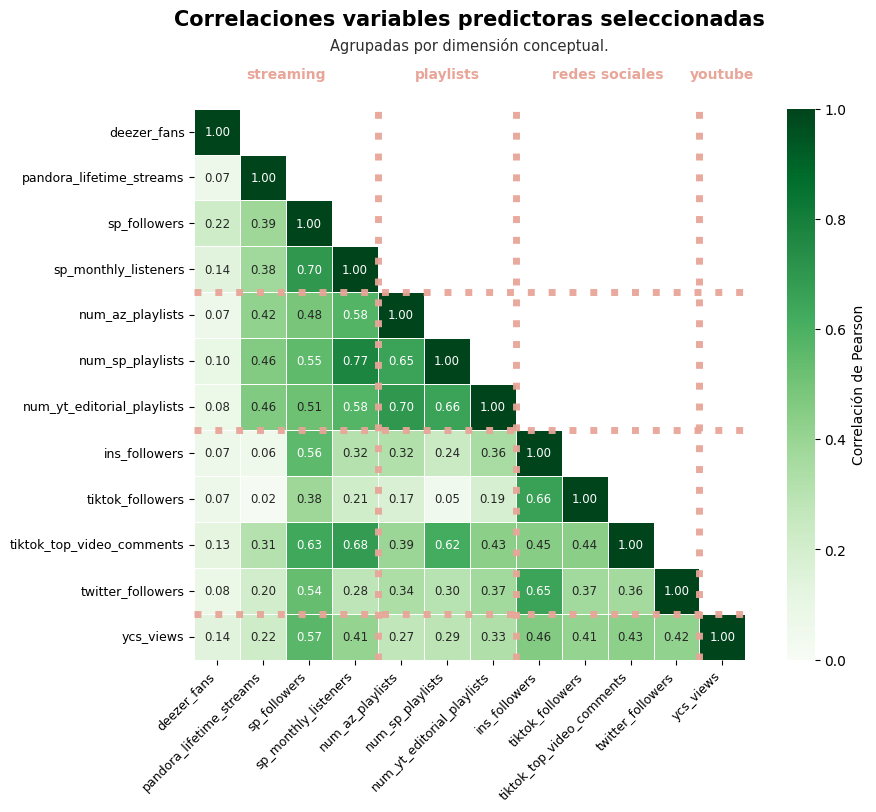

In [24]:
# ============================================================
# Heatmap de correlaciones internas agrupado por dimensión
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Función auxiliar de dimensión
# ------------------------------------------------------------

def asignar_dimension(variable):
    if variable in streaming_cols:
        return "streaming"
    elif variable in playlist_cols:
        return "playlists"
    elif variable in social_cols:
        return "redes sociales"
    elif variable in youtube_cols:
        return "youtube"
    else:
        return "otra"

# ------------------------------------------------------------
# Orden conceptual de dimensiones
# ------------------------------------------------------------

orden_dimensiones = [
    "streaming",
    "playlists",
    "redes sociales",
    "youtube"
]

# ------------------------------------------------------------
# Tabla de orden del subset preliminar
# ------------------------------------------------------------

orden_variables_heatmap = pd.DataFrame({
    "variable": variables_regresion_preliminar
})

orden_variables_heatmap["dimension"] = (
    orden_variables_heatmap["variable"]
    .apply(asignar_dimension)
)

orden_variables_heatmap["orden_dimension"] = (
    orden_variables_heatmap["dimension"]
    .map({dim: i for i, dim in enumerate(orden_dimensiones)})
)

orden_variables_heatmap = (
    orden_variables_heatmap
    .sort_values(["orden_dimension", "variable"])
    .reset_index(drop=True)
)

variables_ordenadas = orden_variables_heatmap["variable"].tolist()

# ------------------------------------------------------------
# Preparación de variables transformadas
# ------------------------------------------------------------

df_heatmap_dim = df.copy()

vars_log_heatmap = [
    col for col in variables_ordenadas
    if col != "sp_popularity"
]

for col in vars_log_heatmap:
    df_heatmap_dim[f"log1p_{col}"] = np.log1p(df_heatmap_dim[col].astype(float))

vars_heatmap = [
    f"log1p_{col}" if col != "sp_popularity" else col
    for col in variables_ordenadas
]

labels_heatmap = [
    col.replace("log1p_", "")
    for col in vars_heatmap
]

# ------------------------------------------------------------
# Matriz de correlación
# ------------------------------------------------------------

corr_heatmap_dim = df_heatmap_dim[vars_heatmap].corr(method="pearson")

# ------------------------------------------------------------
# Máscara para mostrar solo triángulo inferior
# ------------------------------------------------------------

mask = np.triu(
    np.ones_like(corr_heatmap_dim, dtype=bool),
    k=1
)

# ------------------------------------------------------------
# Posiciones de cortes entre dimensiones
# ------------------------------------------------------------

conteo_dimensiones = (
    orden_variables_heatmap
    .groupby("dimension", sort=False)
    .size()
)

cortes = np.cumsum(conteo_dimensiones.values)[:-1]

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 9.5))

sns.heatmap(
    corr_heatmap_dim,
    mask=mask,
    cmap="Greens",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 8.5},
    cbar_kws={"label": "Correlación de Pearson"},
    xticklabels=labels_heatmap,
    yticklabels=labels_heatmap,
    ax=ax
)

# ------------------------------------------------------------
# Líneas separadoras entre dimensiones
# ------------------------------------------------------------

color_separador = "#E8A598"

for corte in cortes:
    ax.axhline(
        corte,
        color=color_separador,
        linewidth=5,
        linestyle=(0, (1, 2)),
        alpha=0.95
    )
    
    ax.axvline(
        corte,
        color=color_separador,
        linewidth=5,
        linestyle=(0, (1, 2)),
        alpha=0.95
    )

# ------------------------------------------------------------
# Título y subtítulo
# ------------------------------------------------------------

# ax.set_title(
#     "Correlaciones variables seleccionadas",
#     fontsize=15,
#     fontweight="bold",
#     pad=24,
#     loc="center"
# )

# ax.text(
#     0.5,
#     1.025,
#     "Agrupadas por dimensión conceptual",
#     transform=ax.transAxes,
#     ha="center",
#     va="bottom",
#     fontsize=10.5,
#     color="#2F2F2F"
# )

ax.set_title(
    "Correlaciones variables predictoras seleccionadas",
    fontsize=15,
    fontweight="bold",
    pad=60,
    loc="center"
)

ax.text(
    0.5,
    1.1,
    "Agrupadas por dimensión conceptual.",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color="#2F2F2F"
)


# ------------------------------------------------------------
# Etiquetas de dimensión sobre el eje superior
# ------------------------------------------------------------

inicio = 0

for dimension, cantidad in conteo_dimensiones.items():
    centro = inicio + cantidad / 2
    
    ax.text(
        centro,
        -0.75,
        dimension,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color= color_separador
    )
    
    inicio += cantidad

# ------------------------------------------------------------
# Estética general
# ------------------------------------------------------------

ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

plt.subplots_adjust(
    top=0.82,
    bottom=0.24,
    left=0.22,
    right=0.92
)

plt.savefig(
    "grafico_heatmap_correlaciones_subset.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()



# PREPARO REGRESION

Criterios finales de selección
asociación con la target
estabilidad entre Pearson/Spearman
reducción de redundancia
interpretabilidad
completitud
representación de dimensiones digitales

In [27]:
# ============================================================
# Consolidación final para avanzar a regresión lineal
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Target y set final de predictoras
# ------------------------------------------------------------

target = "n_shows_24_25"

variables_regresion_final = variables_regresion_preliminar.copy()

# ------------------------------------------------------------
# Control de leakage
# ------------------------------------------------------------

variables_live_predictoras = [
    col for col in variables_regresion_final
    if col in live_cols
]

if len(variables_live_predictoras) > 0:
    raise ValueError(
        f"Hay variables live dentro de las predictoras: {variables_live_predictoras}"
    )

# ------------------------------------------------------------
# Control de existencia de columnas
# ------------------------------------------------------------

columnas_necesarias = [target, "chartmetric_id"] + variables_regresion_final

columnas_faltantes = [
    col for col in columnas_necesarias
    if col not in df.columns
]

if len(columnas_faltantes) > 0:
    raise ValueError(
        f"Columnas faltantes en df: {columnas_faltantes}"
    )

# ------------------------------------------------------------
# Tabla final de documentación de variables
# ------------------------------------------------------------

tabla_variables_regresion = (
    control_regresion_preliminar
    .copy()
    .loc[
        control_regresion_preliminar["variable"].isin(variables_regresion_final)
    ]
    .sort_values(["dimension", "pearson_target"], ascending=[True, False])
    .reset_index(drop=True)
)

tabla_variables_regresion["decision_modelado"] = "incluida_regresion_lineal_preliminar"

display(tabla_variables_regresion)


,variable,dimension,pearson_target,spearman_target,pct_null,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,aparece_en_pares_altos,decision_consolidada,max_corr_dentro_subset,corr_media_dentro_subset,n_pares_subset_070,n_pares_subset_085,decision_modelado
0,num_yt_editorial_playlists,playlists,0.217,0.222,1.91,6,0.796,0.722,True,conservar_preliminar,0.700,0.425,1,0,incluida_regresion_lineal_preliminar
1,num_sp_playlists,playlists,0.201,0.189,0.00,8,0.898,0.790,True,conservar_preliminar,0.774,0.426,1,0,incluida_regresion_lineal_preliminar
2,num_az_playlists,playlists,0.194,0.198,4.84,6,0.996,0.794,True,conservar_preliminar,0.700,0.401,1,0,incluida_regresion_lineal_preliminar
3,ins_followers,redes_sociales,0.176,0.129,6.78,0,NaN,NaN,False,sin_decision_por_no_redundante,0.661,0.376,0,0,incluida_regresion_lineal_preliminar
4,twitter_followers,redes_sociales,0.164,0.129,19.23,0,NaN,NaN,False,sin_decision_por_no_redundante,0.650,0.356,0,0,incluida_regresion_lineal_preliminar
5,tiktok_top_video_comments,redes_sociales,0.137,0.113,0.16,2,0.971,0.947,True,conservar_preliminar,0.681,0.444,0,0,incluida_regresion_lineal_preliminar
6,tiktok_followers,redes_sociales,0.069,0.041,26.64,1,0.927,0.927,True,conservar_preliminar,0.661,0.270,0,0,incluida_regresion_lineal_preliminar
7,sp_followers,streaming,0.196,0.171,0.12,2,0.761,0.731,True,conservar_preliminar,0.701,0.503,1,0,incluida_regresion_lineal_preliminar
8,sp_monthly_listeners,streaming,0.190,0.171,0.12,6,0.928,0.787,True,conservar_preliminar,0.774,0.459,2,0,incluida_regresion_lineal_preliminar
9,pandora_lifetime_streams,streaming,0.187,0.208,1.95,1,0.937,0.937,True,conservar_preliminar,0.462,0.271,0,0,incluida_regresion_lineal_preliminar


In [ ]:

# ------------------------------------------------------------
# Dataset de modelado
# ------------------------------------------------------------

df_modelo_lineal = df[["chartmetric_id", target] + variables_regresion_final].copy()

df_modelo_lineal["log1p_n_shows_24_25"] = np.log1p(
    df_modelo_lineal[target].astype(float)
)

for col in variables_regresion_final:
    df_modelo_lineal[f"log1p_{col}"] = np.log1p(
        df_modelo_lineal[col].astype(float)
    )

variables_regresion_final_log = [
    f"log1p_{col}"
    for col in variables_regresion_final
]

columnas_modelo = [
    "chartmetric_id",
    "log1p_n_shows_24_25"
] + variables_regresion_final_log

df_modelo_lineal = df_modelo_lineal[columnas_modelo].copy()

# ------------------------------------------------------------
# Control de nulos antes de ajustar regresión lineal
# ------------------------------------------------------------

n_artistas_inicial = df_modelo_lineal.shape[0]

df_modelo_lineal_completo = df_modelo_lineal.dropna().copy()

n_artistas_modelo = df_modelo_lineal_completo.shape[0]

print("Artistas iniciales:", n_artistas_inicial)
print("Artistas disponibles para regresión lineal:", n_artistas_modelo)
print("Artistas excluidos por nulos:", n_artistas_inicial - n_artistas_modelo)
print(
    "Porcentaje conservado:",
    round(n_artistas_modelo / n_artistas_inicial * 100, 2)
)

# ------------------------------------------------------------
# Matrices finales para regresión
# ------------------------------------------------------------

X = df_modelo_lineal_completo[variables_regresion_final_log].copy()
y = df_modelo_lineal_completo["log1p_n_shows_24_25"].copy()

ids_modelo = df_modelo_lineal_completo["chartmetric_id"].copy()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

# PRIMER MODELO

In [ ]:
# ============================================================
# Regresión lineal base
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Separación train/test
# ------------------------------------------------------------

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X,
    y,
    ids_modelo,
    test_size=0.25,
    random_state=42
)

# ------------------------------------------------------------
# Ajuste del modelo
# ------------------------------------------------------------

modelo_lineal = LinearRegression()

modelo_lineal.fit(X_train, y_train)

# ------------------------------------------------------------
# Predicción
# ------------------------------------------------------------

y_pred_train = modelo_lineal.predict(X_train)
y_pred_test = modelo_lineal.predict(X_test)

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------

metricas_lineal = pd.DataFrame({
    "set": ["train", "test"],
    "mae": [
        mean_absolute_error(y_train, y_pred_train),
        mean_absolute_error(y_test, y_pred_test)
    ],
    "rmse": [
        mean_squared_error(y_train, y_pred_train) ** 0.5,
        mean_squared_error(y_test, y_pred_test) ** 0.5
    ],
    "r2": [
        r2_score(y_train, y_pred_train),
        r2_score(y_test, y_pred_test)
    ]
})

display(metricas_lineal)

# ------------------------------------------------------------
# Coeficientes
# ------------------------------------------------------------

coeficientes_lineal = pd.DataFrame({
    "variable_transformada": X.columns,
    "coeficiente": modelo_lineal.coef_
})

coeficientes_lineal["variable"] = (
    coeficientes_lineal["variable_transformada"]
    .str.replace("log1p_", "", regex=False)
)

coeficientes_lineal = (
    coeficientes_lineal
    .merge(
        tabla_variables_regresion[["variable", "dimension"]],
        on="variable",
        how="left"
    )
    .sort_values("coeficiente", key=lambda x: x.abs(), ascending=False)
    .reset_index(drop=True)
)

display(coeficientes_lineal)